# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [17]:
import qiskit
import qiskit_aer
from qiskit.visualization import plot_distribution, plot_histogram

from ewfs.noise_models import bitflip_model
from ewfs.scenario import EWFS
from ewfs.utils import decode_results

## Sanity checks (for majority vote approach)

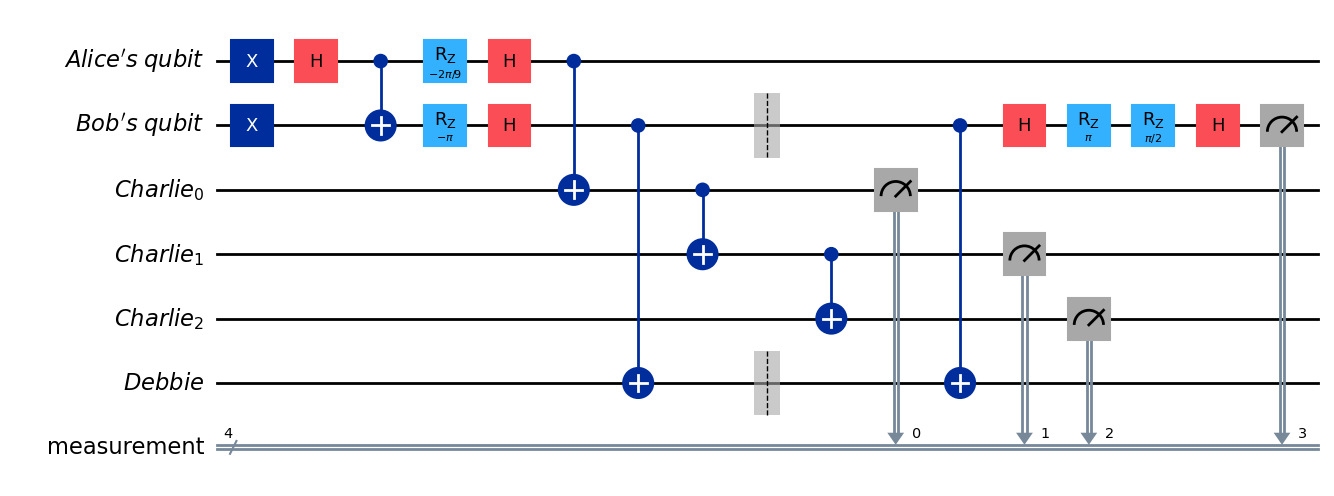

In [24]:
alice_setting = "peek"
bob_setting = "reverse_2"
charlie_size = 3
debbie_size = 1
strategy = "majority_vote"

ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

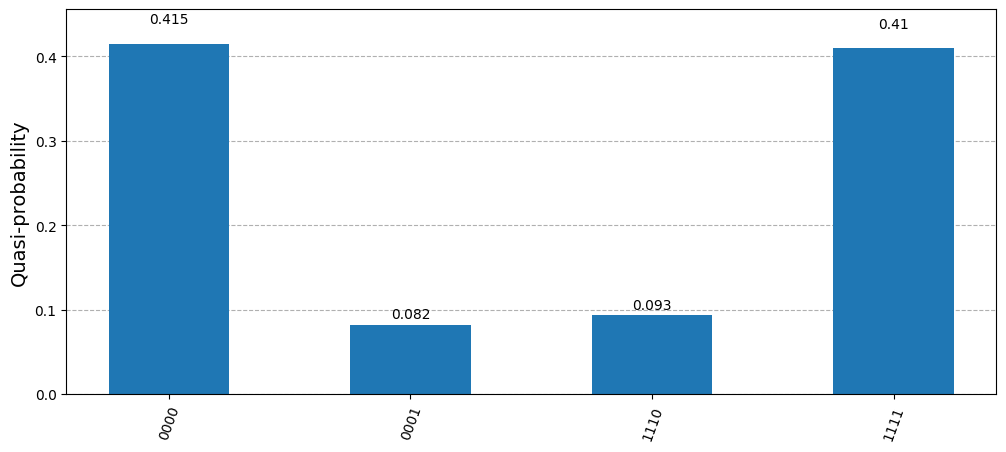

In [25]:
noise_bit_flip = bitflip_model(0.03)
simulator = qiskit_aer.AerSimulator()

transpiled_qc = qiskit.transpile(qc, simulator, basis_gates=noise_bit_flip.basis_gates)

shots = 10_000
job = simulator.run(transpiled_qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

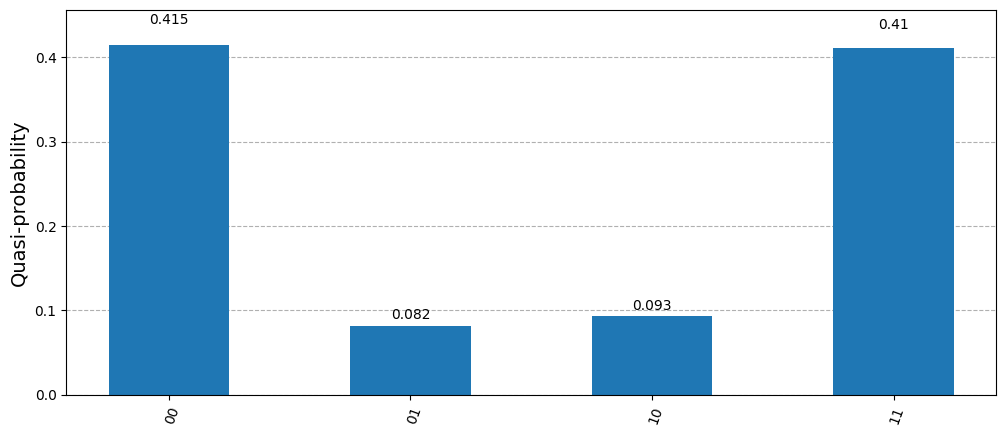

In [26]:
results = {(alice_setting, bob_setting): probabilities}
dec_res = decode_results(results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Settings

In [73]:
from ewfs.experiment import run_experiment


settings = [
    ("peek", "reverse_1"),
    ("peek", "reverse_2"),
    ("reverse_2", "reverse_1"),
    ("reverse_2", "reverse_2"),
]
run_experiment(settings=settings, strategy="random")